In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
#Завантаження даних
file_id = '1sZEVfLqlso3cCgjqcLv2lOnQ3DuJU1ji'
download_url = f'https://drive.google.com/uc?id={file_id}'
task_df = pd.read_csv(download_url)
task_df.head()

,Показник,Територіальний розріз,Напрям природоохоронної діяльності,Вид економічної діяльності,Періодичність,Період,Значення cпостереження
0,Капітальні інвестиції на охорону навколишнього...,Вінницька,Науково-дослідні роботи природоохоронного спря...,Усього,Річна,2021,NaN
1,Капітальні інвестиції на охорону навколишнього...,Вінницька,Науково-дослідні роботи природоохоронного спря...,Усього,Річна,2022,NaN
2,Капітальні інвестиції на охорону навколишнього...,Вінницька,Науково-дослідні роботи природоохоронного спря...,Усього,Річна,2023,NaN
3,Капітальні інвестиції на охорону навколишнього...,Вінницька,Науково-дослідні роботи природоохоронного спря...,Усього,Річна,2024,NaN
4,Капітальні інвестиції на охорону навколишнього...,Вінницька,Науково-дослідні роботи природоохоронного спря...,Усього,Річна,2025,25.0


In [5]:
task_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5100 entries, 0 to 5099
Data columns (total 7 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Показник                            5100 non-null   object 
 1   Територіальний розріз               5100 non-null   object 
 2   Напрям природоохоронної діяльності  5100 non-null   object 
 3   Вид економічної діяльності          5100 non-null   object 
 4   Періодичність                       5100 non-null   object 
 5   Період                              5100 non-null   int64  
 6   Значення cпостереження              3720 non-null   float64
dtypes: float64(1), int64(1), object(5)
memory usage: 279.0+ KB


In [6]:
task_df['Територіальний розріз'].unique()

array(['Вінницька', 'Волинська', 'Дніпропетровська', 'Донецька',
       'Житомирська', 'Закарпатська', 'Запорізька', 'Івано-Франківська',
       'Київська', 'Кіровоградська', 'Луганська', 'Львівська',
       'Миколаївська', 'Одеська', 'Полтавська', 'Рівненська', 'Сумська',
       'Тернопільська', 'Харківська', 'Херсонська', 'Хмельницька',
       'Черкаська', 'Чернівецька', 'Чернігівська', 'Київ'], dtype=object)

In [7]:
task_df = task_df.dropna(subset=['Значення cпостереження'])

task_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3720 entries, 4 to 5099
Data columns (total 7 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Показник                            3720 non-null   object 
 1   Територіальний розріз               3720 non-null   object 
 2   Напрям природоохоронної діяльності  3720 non-null   object 
 3   Вид економічної діяльності          3720 non-null   object 
 4   Періодичність                       3720 non-null   object 
 5   Період                              3720 non-null   int64  
 6   Значення cпостереження              3720 non-null   float64
dtypes: float64(1), int64(1), object(5)
memory usage: 232.5+ KB


In [8]:
#При вантаженні даних з держстату, значення спостережень, було в маштабі тисячі. Переводимо дані в актуальні одиниці
task_df['Значення cпостереження'] = task_df['Значення cпостереження'] * 1000
task_df.head()

,Показник,Територіальний розріз,Напрям природоохоронної діяльності,Вид економічної діяльності,Періодичність,Період,Значення cпостереження
4,Капітальні інвестиції на охорону навколишнього...,Вінницька,Науково-дослідні роботи природоохоронного спря...,Усього,Річна,2025,25000.0
5,Капітальні інвестиції на охорону навколишнього...,Вінницька,Охорона атмосферного повітря і проблеми зміни ...,Усього,Річна,2021,1302700.0
6,Капітальні інвестиції на охорону навколишнього...,Вінницька,Охорона атмосферного повітря і проблеми зміни ...,Усього,Річна,2022,17372000.0
7,Капітальні інвестиції на охорону навколишнього...,Вінницька,Охорона атмосферного повітря і проблеми зміни ...,Усього,Річна,2023,5050900.0
8,Капітальні інвестиції на охорону навколишнього...,Вінницька,Охорона атмосферного повітря і проблеми зміни ...,Усього,Річна,2024,842200.0


In [10]:
#завантаження чистового варіанту датасету
from google.colab import drive
drive.mount('/content/drive')
task_df.to_csv('/content/drive/MyDrive/internship/clean_data.csv', index=False, encoding="utf-8-sig")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
# Додати новий стовпчик з витратами у мільйонах
task_df['Витрати_млн'] = task_df['Значення cпостереження'] / 1e6
task_df.head()

,Показник,Територіальний розріз,Напрям природоохоронної діяльності,Вид економічної діяльності,Періодичність,Період,Значення cпостереження,Витрати_млн
4,Капітальні інвестиції на охорону навколишнього...,Вінницька,Науково-дослідні роботи природоохоронного спря...,Усього,Річна,2025,25000.0,0.0250
5,Капітальні інвестиції на охорону навколишнього...,Вінницька,Охорона атмосферного повітря і проблеми зміни ...,Усього,Річна,2021,1302700.0,1.3027
6,Капітальні інвестиції на охорону навколишнього...,Вінницька,Охорона атмосферного повітря і проблеми зміни ...,Усього,Річна,2022,17372000.0,17.3720
7,Капітальні інвестиції на охорону навколишнього...,Вінницька,Охорона атмосферного повітря і проблеми зміни ...,Усього,Річна,2023,5050900.0,5.0509
8,Капітальні інвестиції на охорону навколишнього...,Вінницька,Охорона атмосферного повітря і проблеми зміни ...,Усього,Річна,2024,842200.0,0.8422


In [12]:
yearly_stats = task_df.groupby('Період')['Витрати_млн'].describe().round(2)

yearly_summary = pd.DataFrame({
    "Avg": task_df.groupby('Період')['Витрати_млн'].mean().round(2),
    "Median": task_df.groupby('Період')['Витрати_млн'].median().round(2),
    "Min": task_df.groupby('Період')['Витрати_млн'].min().round(2),
    "Max": task_df.groupby('Період')['Витрати_млн'].max().round(2)
})

combined_stats = yearly_stats.join(yearly_summary)

combined_stats

,count,mean,std,min,25%,50%,75%,max,Avg,Median,Min,Max
Період,,,,,,,,,,,,
2021,784.0,133.06,503.61,0.0,0.89,8.60,67.47,8949.14,133.06,8.60,0.0,8949.14
2022,708.0,87.95,336.59,0.0,0.07,2.62,41.37,5487.97,87.95,2.62,0.0,5487.97
2023,694.0,108.08,393.19,0.0,0.08,3.28,49.43,6434.16,108.08,3.28,0.0,6434.16
2024,822.0,113.65,429.66,0.0,0.18,5.59,51.11,7260.81,113.65,5.59,0.0,7260.81
2025,712.0,145.31,552.45,0.0,0.55,9.98,67.87,9417.77,145.31,9.98,0.0,9417.77


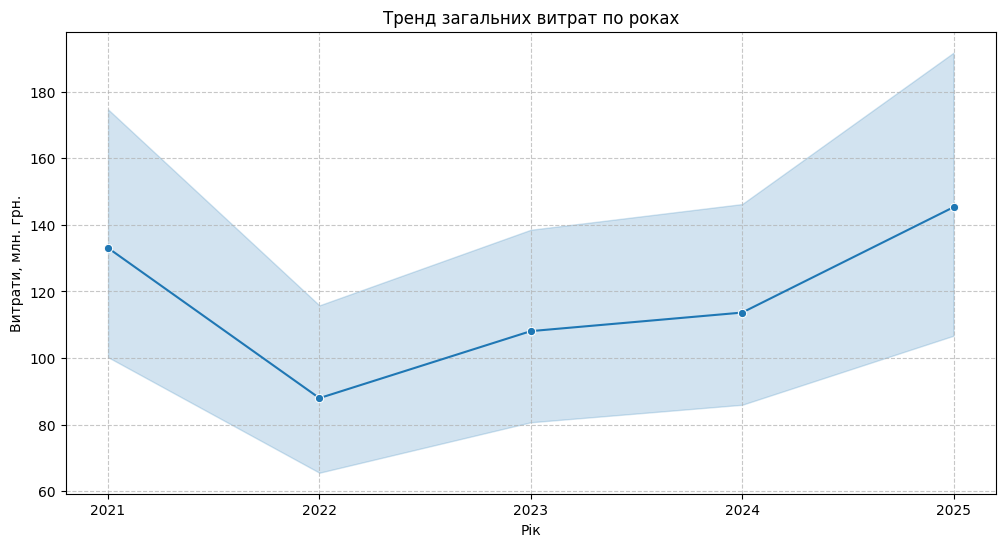

In [13]:
plt.figure(figsize=(12,6))
ax = sns.lineplot(
    data=task_df,
    x='Період',
    y='Витрати_млн',
    marker='o'
)

plt.xticks(task_df['Період'].unique())
plt.title("Тренд загальних витрат по роках")
plt.xlabel("Рік")
plt.ylabel("Витрати, млн. грн.")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

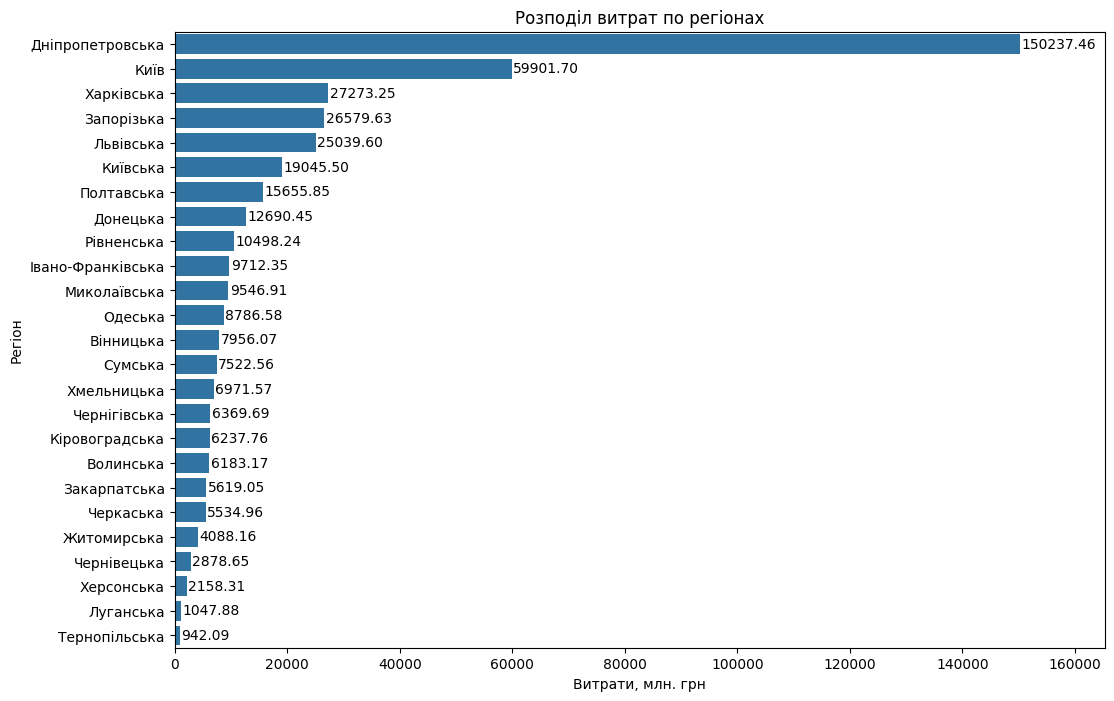

In [14]:
plt.figure(figsize=(12,8))
ax = sns.barplot(
    data=task_df,
    y='Територіальний розріз',
    x='Витрати_млн',
    estimator=sum,
    errorbar=None,
    order=task_df.groupby('Територіальний розріз')['Витрати_млн'].sum().sort_values(ascending=False).index
)

plt.title("Розподіл витрат по регіонах")
plt.xlabel("Витрати, млн. грн")
plt.ylabel("Регіон")

# додати підписи значень на барах
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', padding=1)

# встановити верхню межу по X з запасом
max_value = task_df.groupby('Територіальний розріз')['Витрати_млн'].sum().max()
plt.xlim(0, max_value * 1.1)  # +10% запасу від найбільшого бара


plt.show()


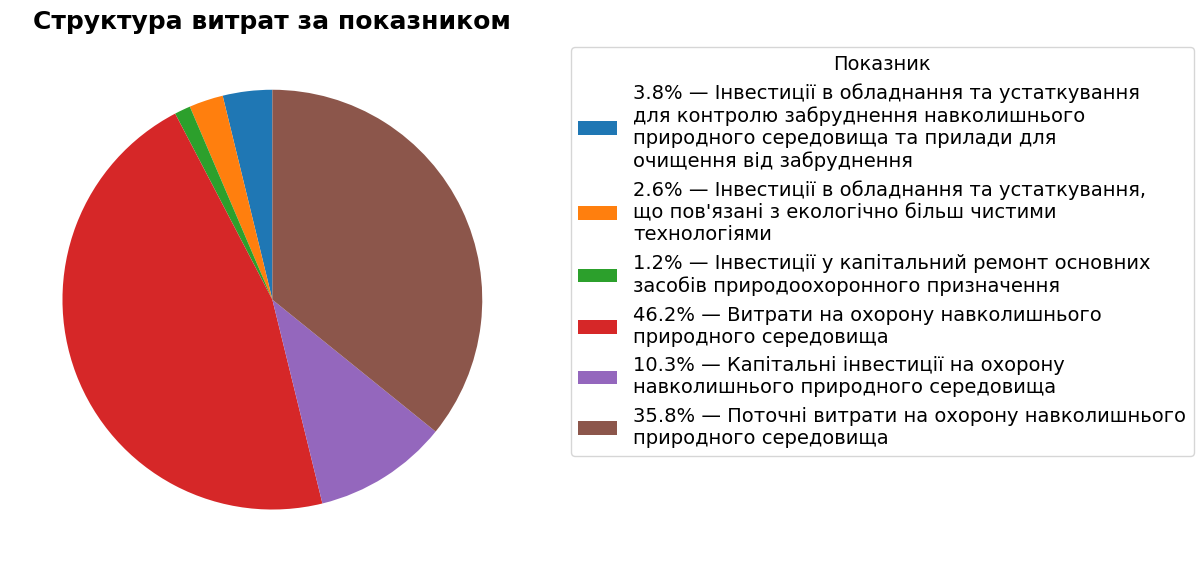

In [15]:
import textwrap

plt.figure(figsize=(11,8))
indicator_data = task_df.groupby('Показник')['Витрати_млн'].sum()

# малюємо діаграму без підписів
plt.pie(
    indicator_data,
    labels=None,
    startangle=90
)

plt.title("Структура витрат за показником", fontsize=18, fontweight='bold', loc='center')


# формуємо легенду з назвами + %
percentages = (indicator_data / indicator_data.sum() * 100).round(1)

# переносимо довгі рядки для компактності
labels = [f"{pct}% — {textwrap.fill(name, 40)}" for name, pct in zip(indicator_data.index, percentages)]

plt.legend(
    labels,
    title="Показник",
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    fontsize=14,          # більший шрифт
    title_fontsize=14     # більший шрифт заголовка
)

plt.tight_layout()
plt.show()


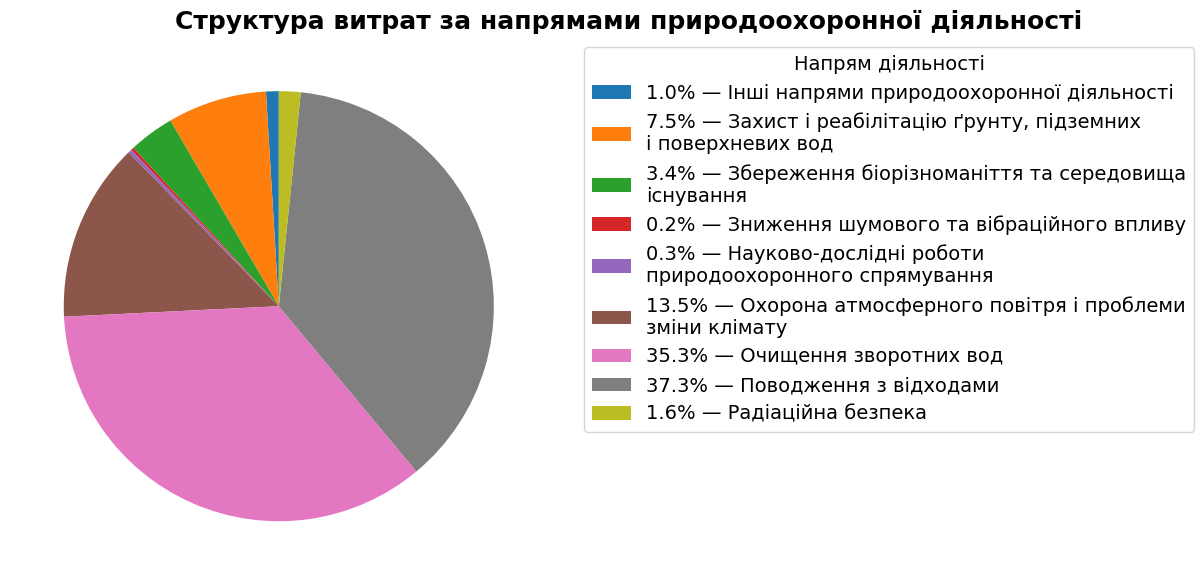

In [16]:
plt.figure(figsize=(11,8))
activity_data = task_df.groupby('Напрям природоохоронної діяльності')['Витрати_млн'].sum()

# малюємо діаграму без підписів
plt.pie(
    activity_data,
    labels=None,          # без назв на секторах
    startangle=90
)

plt.title("Структура витрат за напрямами природоохоронної діяльності", fontsize=18, fontweight='bold', x=1.15)

# формуємо легенду з назвами + %
percentages = (activity_data / activity_data.sum() * 100).round(1)

# переносимо довгі рядки для компактності
labels = [f"{pct}% — {textwrap.fill(name, 40)}" for name, pct in zip(activity_data.index, percentages)]

plt.legend(
    labels,
    title="Напрям діяльності",
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    fontsize=14,          # більший шрифт
    title_fontsize=14     # більший шрифт заголовка
)

plt.tight_layout()
plt.show()


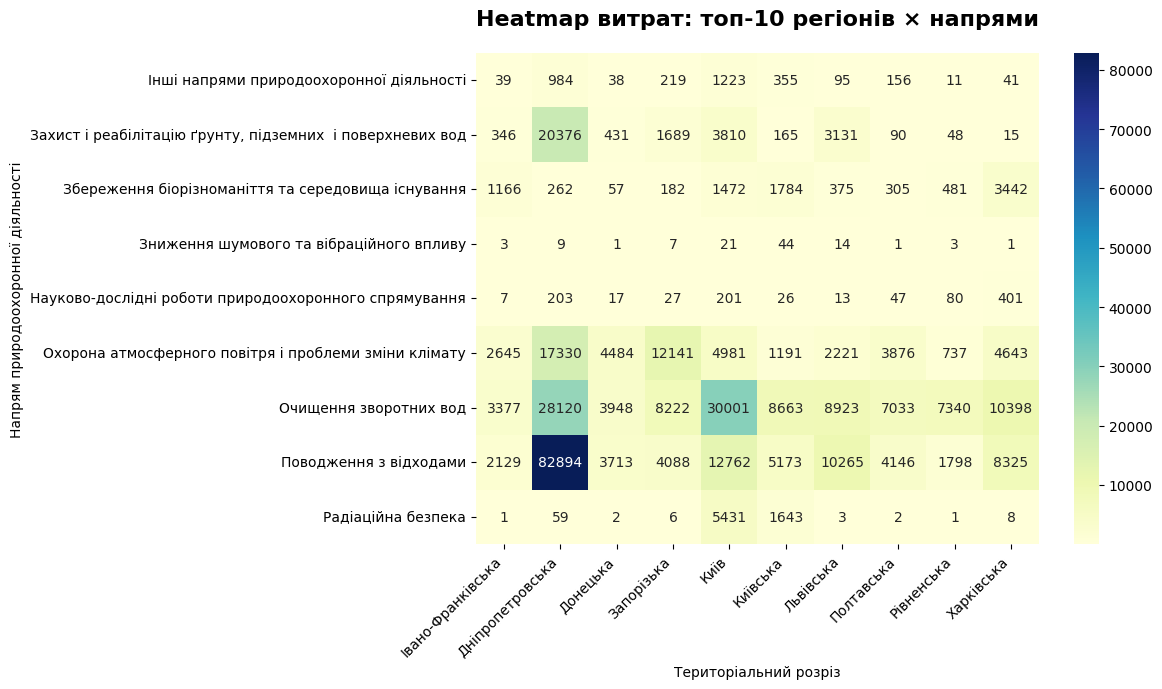

In [22]:
# топ-10 регіонів за витратами
top_regions = task_df.groupby('Територіальний розріз')['Витрати_млн'].sum().nlargest(10).index
filtered_df = task_df[task_df['Територіальний розріз'].isin(top_regions)]

pivot_table = filtered_df.pivot_table(
    values='Витрати_млн',
    index='Напрям природоохоронної діяльності',
    columns='Територіальний розріз',
    aggfunc='sum',
    fill_value=0
)

plt.figure(figsize=(12,7))
sns.heatmap(pivot_table, cmap="YlGnBu", annot=True, fmt=".0f")

plt.title("Heatmap витрат: топ-10 регіонів × напрями", fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()